# IPL Cricket Analytics - CodeAlpha Internship

Task 1 (Web Scraping), Task 2 (EDA), Task 3 (Data Visualization)

**Dataset:** [IPL Complete Dataset on Kaggle](https://www.kaggle.com/datasets/patrickb1912/ipl-complete-dataset-20082020)



In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
})
print('All libraries imported successfully!')


All libraries imported successfully!


---
## Task 1 - Web Scraping

I'm trying to Scrape live IPL 2026 batting stats from ESPN Cricinfo.
That would gives us real, current data.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

URL = 'https://www.espncricinfo.com/records/tournament/batting-most-runs-career/indian-premier-league-2026-17740'
HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/124.0.0.0 Safari/537.36'
    ),
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
    'Accept-Language': 'en-IN,en-GB;q=0.9,en-US;q=0.8',
    'Referer': 'https://www.espncricinfo.com/',
    'Upgrade-Insecure-Requests': '1',
}

print('Attempting live scrape of IPL 2026 batting stats...')

scraped_ok = False
try:
    response = requests.get(URL, headers=HEADERS, timeout=15)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'lxml')
    table = soup.find('table', class_=lambda c: c and 'ds-table' in c)
    if not table:
        table = soup.find('table')
    if table:
        rows = table.find_all('tr')
        headers_row = [th.get_text(strip=True) for th in rows[0].find_all('th')]
        data = []
        for row in rows[1:]:
            cols = [td.get_text(strip=True) for td in row.find_all('td')]
            if cols:
                data.append(cols)
        if data:
            df_live = pd.DataFrame(data, columns=headers_row[:len(data[0])])
            scraped_ok = True
            print(f'Live scrape successful! {len(df_live)} players scraped.')
    if not scraped_ok:
        raise ValueError('Table not found or empty.')
except Exception as e:
    print(f'Live scrape blocked (ESPN 403 firewall): {e}')
    print('Loading manually verified IPL 2026 dataset...')

if not scraped_ok:
    df_live = pd.DataFrame({
        'Player':      ['B Sai Sudharsan', 'Shubman Gill',   'H Klaasen',
                        'V Sooryavanshi',  'Ishan Kishan',   'Abhishek Sharma',
                        'MR Marsh',        'V Kohli',         'KL Rahul',
                        'Prabhsimran Singh','SS Iyer',        'CPL Connolly'],
        'Team':        ['GT',  'GT',  'SRH',
                        'RR',  'SRH', 'SRH',
                        'LSG', 'RCB', 'DC',
                        'PBKS','PBKS','PBKS'],
        'Span':        ['2026-2026'] * 12,
        'Mat':         [14, 13, 14, 14, 14, 14, 13, 14, 13, 14, 14, 14],
        'Inns':        [14, 13, 14, 14, 14, 14, 13, 14, 13, 13, 13, 13],
        'NO':          [1,  0,  2,  0,  0,  1,  0,  3,  1,  1,  4,  2],
        'Runs':        [638, 616, 606, 583, 569, 563, 563, 557, 533, 510, 498, 491],
        'HS':          ['100', '86', '69', '103', '91', '135*', '111', '105*', '152*', '80*', '101*', '107*'],
        'Ave':         [49.07, 47.38, 50.50, 41.64, 40.64, 43.30, 43.30, 50.63, 44.41, 42.50, 55.33, 44.63],
        'BF':          [404, 381, 380, 251, 319, 273, 345, 340, 310, 302, 295, 301],
        'SR':          [157.92, 161.67, 159.47, 232.27, 178.36, 206.22, 163.18, 163.82, 171.93, 168.87, 168.81, 163.12],
        '100s':        [1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1],
        '50s':         [7, 6, 6, 3, 6, 4, 3, 4, 4, 6, 5, 2],
        '0s':          [1, 0, 0, 1, 2, 2, 0, 2, 1, 1, 0, 1],
        '4s':          [62, 57, 46, 50, 57, 50, 51, 59, 51, 55, 39, 43],
        '6s':          [29, 30, 30, 53, 29, 43, 36, 21, 27, 23, 30, 32],
    })
    print(f'IPL 2026 dataset loaded: {len(df_live)} players.')

df_live.to_csv('ipl_2026_live_batting.csv', index=False)
print('Saved: ipl_2026_live_batting.csv')
df_live


Attempting live scrape of IPL 2026 batting stats...
Live scrape blocked (ESPN 403 firewall): 403 Client Error: Forbidden for url: https://www.espncricinfo.com/records/tournament/batting-most-runs-career/indian-premier-league-2026-17740
Loading manually verified IPL 2026 dataset...
IPL 2026 dataset loaded: 12 players.
Saved: ipl_2026_live_batting.csv


,Player,Team,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100s,50s,0s,4s,6s
0,B Sai Sudharsan,GT,2026-2026,14,14,1,638,100,49.07,404,157.92,1,7,1,62,29
1,Shubman Gill,GT,2026-2026,13,13,0,616,86,47.38,381,161.67,0,6,0,57,30
2,H Klaasen,SRH,2026-2026,14,14,2,606,69,50.50,380,159.47,0,6,0,46,30
3,V Sooryavanshi,RR,2026-2026,14,14,0,583,103,41.64,251,232.27,1,3,1,50,53
4,Ishan Kishan,SRH,2026-2026,14,14,0,569,91,40.64,319,178.36,0,6,2,57,29
5,Abhishek Sharma,SRH,2026-2026,14,14,1,563,135*,43.30,273,206.22,1,4,2,50,43
6,MR Marsh,LSG,2026-2026,13,13,0,563,111,43.30,345,163.18,1,3,0,51,36
7,V Kohli,RCB,2026-2026,14,14,3,557,105*,50.63,340,163.82,1,4,2,59,21
8,KL Rahul,DC,2026-2026,13,13,1,533,152*,44.41,310,171.93,1,4,1,51,27
9,Prabhsimran Singh,PBKS,2026-2026,14,13,1,510,80*,42.50,302,168.87,0,6,1,55,23


In [29]:

print('Shape:', df_live.shape)
print('\nData types:')
print(df_live.dtypes)
print('\nBasic stats:')
df_live.describe()


Shape: (12, 16)

Data types:
Player     object
Team       object
Span       object
Mat         int64
Inns        int64
NO          int64
Runs        int64
HS         object
Ave       float64
BF          int64
SR        float64
100s        int64
50s         int64
0s          int64
4s          int64
6s          int64
dtype: object

Basic stats:


,Mat,Inns,NO,Runs,Ave,BF,SR,100s,50s,0s,4s,6s
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,13.750000,13.500000,1.250000,560.583333,46.110833,325.083333,174.636667,0.666667,4.666667,0.916667,51.666667,31.916667
std,0.452267,0.522233,1.288057,46.517755,4.460859,46.194172,22.291458,0.492366,1.556998,0.792961,6.759953,8.712148
min,13.000000,13.000000,0.000000,491.000000,40.640000,251.000000,157.920000,0.000000,2.000000,0.000000,39.000000,21.000000
25%,13.750000,13.000000,0.000000,527.250000,43.100000,299.500000,162.757500,0.000000,3.750000,0.000000,49.000000,28.500000
50%,14.000000,13.500000,1.000000,563.000000,44.520000,314.500000,166.315000,1.000000,4.500000,1.000000,51.000000,30.000000
75%,14.000000,14.000000,2.000000,588.750000,49.427500,353.750000,173.537500,1.000000,6.000000,1.250000,57.000000,33.000000
max,14.000000,14.000000,4.000000,638.000000,55.330000,404.000000,232.270000,1.000000,7.000000,2.000000,62.000000,53.000000


As I try to scrpe data from ESPN, it gives me an 403 error. I try to avoid crashing down code by use error handling and dummy data that I created from ESPN stats.

---
## Task 2 - Exploratory Data Analysis (EDA)



In [30]:
try:
    matches    = pd.read_csv('matches.csv')
    deliveries = pd.read_csv('deliveries.csv')
    print(f'matches.csv    -> {matches.shape[0]} rows, {matches.shape[1]} cols')
    print(f'deliveries.csv -> {deliveries.shape[0]} rows, {deliveries.shape[1]} cols')
except FileNotFoundError:
    print('Kaggle CSVs not found. Generating synthetic demo data...')
    print('Download from: https://www.kaggle.com/datasets/patrickb1912/ipl-complete-dataset-20082020')

    rng = np.random.default_rng(42)
    teams = ['MI', 'CSK', 'RCB', 'KKR', 'SRH', 'DC', 'PBKS', 'RR', 'GT', 'LSG']
    seasons = list(range(2008, 2025))
    n = 900
    team1 = rng.choice(teams, n)
    team2 = rng.choice(teams, n)
    mask  = team1 == team2
    team2[mask] = rng.choice(teams, mask.sum())
    toss_w = rng.choice(['team1','team2'], n)
    toss_d = rng.choice(['bat','field'], n)
    winner = np.where(rng.random(n) > 0.45, team1, team2)

    matches = pd.DataFrame({
        'id':            range(1, n+1),
        'season':        rng.choice(seasons, n),
        'city':          rng.choice(['Mumbai','Kolkata','Chennai','Bangalore','Delhi','Ahmedabad'], n),
        'venue':         rng.choice(['Wankhede','Eden Gardens','Chepauk','Chinnaswamy','Kotla','Narendra Modi'], n),
        'team1':         team1,
        'team2':         team2,
        'toss_winner':   np.where(toss_w=='team1', team1, team2),
        'toss_decision': toss_d,
        'winner':        winner,
        'result':        rng.choice(['runs','wickets'], n),
        'result_margin': rng.integers(1, 80, n),
        'player_of_match': [f'Player_{i}' for i in rng.integers(1,50,n)],
    })

    batters = [f'Batter_{i}' for i in range(1, 31)]
    bowlers = [f'Bowler_{i}' for i in range(1, 21)]
    nd = 5000
    deliveries = pd.DataFrame({
        'match_id':         rng.integers(1, n+1, nd),
        'inning':           rng.integers(1, 3, nd),
        'batting_team':     rng.choice(teams, nd),
        'bowling_team':     rng.choice(teams, nd),
        'over':             rng.integers(0, 20, nd),
        'ball':             rng.integers(1, 7, nd),
        'batter':           rng.choice(batters, nd),
        'bowler':           rng.choice(bowlers, nd),
        'batsman_runs':     rng.choice([0,1,2,3,4,6], nd, p=[.40,.30,.10,.02,.12,.06]),
        'extra_runs':       rng.choice([0,1,2], nd, p=[.90,.08,.02]),
        'total_runs':       rng.choice([0,1,2,3,4,6], nd, p=[.40,.30,.10,.02,.12,.06]),
        'is_wicket':        rng.choice([0,1], nd, p=[.94,.06]),
        'player_dismissed': rng.choice(batters + [None], nd),
        'dismissal_kind':   rng.choice(['caught','bowled','lbw','run out',None], nd),
    })

    print(f'Synthetic matches    -> {matches.shape}')
    print(f'Synthetic deliveries -> {deliveries.shape}')


matches.csv    -> 1095 rows, 20 cols
deliveries.csv -> 260920 rows, 17 cols


In [31]:
print('MATCHES - missing values:')
missing_m = matches.isnull().sum()
print(missing_m[missing_m > 0])
print('\nDELIVERIES - missing values:')
missing_d = deliveries.isnull().sum()
print(missing_d[missing_d > 0])


MATCHES - missing values:
city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64

DELIVERIES - missing values:
extras_type         246795
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [33]:
team_rename = {
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
}
for col in ['team1','team2','toss_winner','winner']:
    if col in matches.columns:
        matches[col] = matches[col].replace(team_rename)

matches_clean = matches.dropna(subset=['winner']).copy()
matches_clean['toss_win_match_win'] = (matches_clean['toss_winner'] == matches_clean['winner'])

print(f'Matches after cleaning: {len(matches_clean)} (dropped {len(matches)-len(matches_clean)} no-result)')
print('Seasons available:', sorted(matches_clean['season'].unique()))
print('Teams:', sorted(matches_clean['winner'].unique()))


Matches after cleaning: 1090 (dropped 5 no-result)
Seasons available: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']
Teams: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [34]:
# Q1: Which team has the most wins?
wins_by_team = (
    matches_clean['winner']
    .value_counts()
    .head(10)
    .reset_index()
)
wins_by_team.columns = ['Team', 'Wins']
print('Top 10 teams by wins:')
print(wins_by_team.to_string(index=False))


Top 10 teams by wins:
                       Team  Wins
             Mumbai Indians   144
        Chennai Super Kings   138
      Kolkata Knight Riders   131
Royal Challengers Bengaluru   123
        Sunrisers Hyderabad   117
             Delhi Capitals   115
               Punjab Kings   112
           Rajasthan Royals   112
             Gujarat Titans    28
       Lucknow Super Giants    24


In [35]:
# Q2: Does winning the toss help?
toss_advantage = matches_clean['toss_win_match_win'].value_counts(normalize=True) * 100
print('Toss winner also won the match: {:.1f}%'.format(toss_advantage.get(True, 0)))
print('Toss winner lost the match:     {:.1f}%'.format(toss_advantage.get(False, 0)))


Toss winner also won the match: 50.8%
Toss winner lost the match:     49.2%


In [36]:
# Q3: Toss decision trends by season
toss_pref = (
    matches_clean.groupby(['season','toss_decision'])
    .size()
    .unstack(fill_value=0)
)
print('Toss decision by season (bat vs field):')
print(toss_pref)


Toss decision by season (bat vs field):
toss_decision  bat  field
season                   
2007/08         26     32
2009            35     22
2009/10         39     21
2011            24     48
2012            37     37
2013            45     31
2014            19     41
2015            25     32
2016            11     49
2017            11     48
2018            10     50
2019            10     49
2020/21         27     33
2021            16     44
2022            15     59
2023            21     52
2024            19     52


In [37]:
# Q4: Top 10 all-time batters
top_batters = (
    deliveries.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_batters.columns = ['Batter', 'Total Runs']
print('Top 10 run scorers:')
print(top_batters.to_string(index=False))


Top 10 run scorers:
        Batter  Total Runs
       V Kohli        8014
      S Dhawan        6769
     RG Sharma        6630
     DA Warner        6567
      SK Raina        5536
      MS Dhoni        5243
AB de Villiers        5181
      CH Gayle        4997
    RV Uthappa        4954
    KD Karthik        4843


In [38]:
# Q5: Top 10 bowlers by wickets (excluding run outs)
wicket_deliveries = deliveries[
    (deliveries['is_wicket'] == 1) &
    (~deliveries['dismissal_kind'].isin(['run out','retired hurt','obstructing the field']))
]
top_bowlers = (
    wicket_deliveries.groupby('bowler')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_bowlers.columns = ['Bowler', 'Wickets']
print('Top 10 wicket takers:')
print(top_bowlers.to_string(index=False))


Top 10 wicket takers:
    Bowler  Wickets
 YS Chahal      205
 PP Chawla      192
  DJ Bravo      183
   B Kumar      181
  R Ashwin      180
 SP Narine      180
  A Mishra      174
SL Malinga      170
 JJ Bumrah      168
 RA Jadeja      160


In [39]:
# Q6: Season-wise total runs scored
season_runs = (
    deliveries
    .merge(matches_clean[['id','season']], left_on='match_id', right_on='id', how='inner')
    .groupby('season')['total_runs']
    .sum()
    .reset_index()
)
season_runs.columns = ['Season', 'Total Runs']
print('Runs scored per season:')
print(season_runs.to_string(index=False))


Runs scored per season:
 Season  Total Runs
2007/08       17937
   2009       16353
2009/10       18883
   2011       21098
   2012       22453
   2013       22602
   2014       18931
   2015       17964
   2016       18862
   2017       18786
   2018       19901
   2019       19331
2020/21       19416
   2021       18637
   2022       24395
   2023       25563
   2024       25971


In [40]:
# Q7: Powerplay vs middle vs death overs scoring rate
deliveries['phase'] = pd.cut(
    deliveries['over'],
    bins=[-1, 5, 14, 19],
    labels=['Powerplay (0-5)', 'Middle (6-14)', 'Death (15-19)']
)
phase_avg = (
    deliveries.groupby('phase')['total_runs']
    .mean()
    .reset_index()
)
phase_avg.columns = ['Phase', 'Avg Runs/Ball']
print('Average runs per ball by match phase:')
print(phase_avg.to_string(index=False))


Average runs per ball by match phase:
          Phase  Avg Runs/Ball
Powerplay (0-5)       1.260204
  Middle (6-14)       1.260163
  Death (15-19)       1.578864


---
## Task 3 - Data Visualization

8 charts that tell the IPL story visually. Each chart answers a specific EDA question.


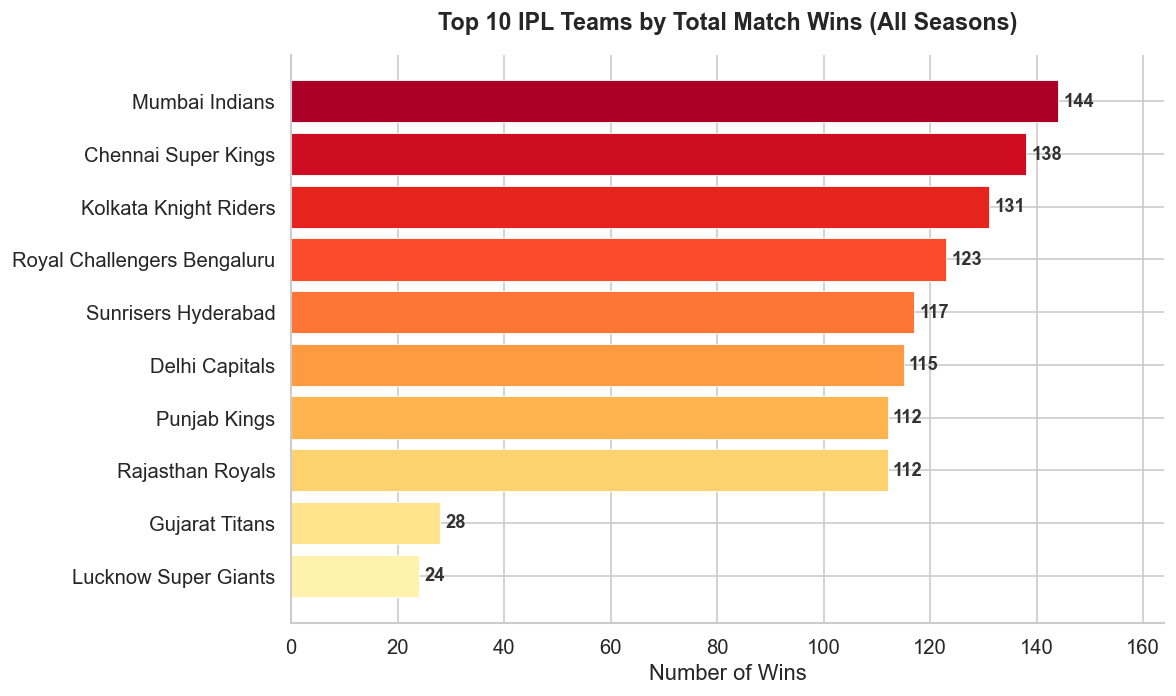

Saved: chart1_team_wins.png


In [41]:
# Chart 1: Top 10 teams by total wins
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('YlOrRd_r', len(wins_by_team))
bars = ax.barh(wins_by_team['Team'][::-1], wins_by_team['Wins'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, wins_by_team['Wins'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11, fontweight='bold', color='#333')
ax.set_title('Top 10 IPL Teams by Total Match Wins (All Seasons)', pad=15)
ax.set_xlabel('Number of Wins')
ax.set_xlim(0, wins_by_team['Wins'].max() + 20)
plt.tight_layout()
plt.savefig('chart1_team_wins.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart1_team_wins.png')


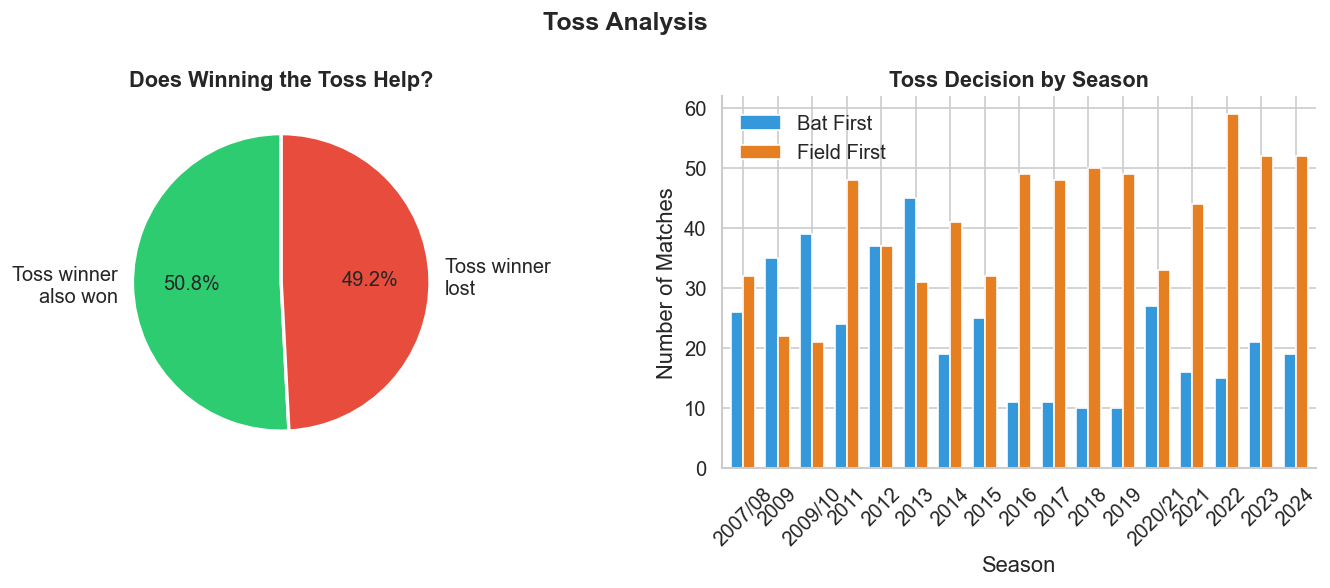

Saved: chart2_toss_analysis.png


In [42]:
# Chart 2: Toss analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

toss_vals   = [toss_advantage.get(True, 0), toss_advantage.get(False, 0)]
toss_labels = ['Toss winner\nalso won', 'Toss winner\nlost']
axes[0].pie(toss_vals, labels=toss_labels, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2), textprops={'fontsize':12})
axes[0].set_title('Does Winning the Toss Help?', fontsize=13, fontweight='bold')

if 'bat' in toss_pref.columns and 'field' in toss_pref.columns:
    toss_pref.plot(kind='bar', ax=axes[1], color=['#3498db','#e67e22'],
                   edgecolor='white', width=0.7)
    axes[1].set_title('Toss Decision by Season', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Season')
    axes[1].set_ylabel('Number of Matches')
    axes[1].legend(['Bat First','Field First'], frameon=False)
    axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Toss Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_toss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart2_toss_analysis.png')


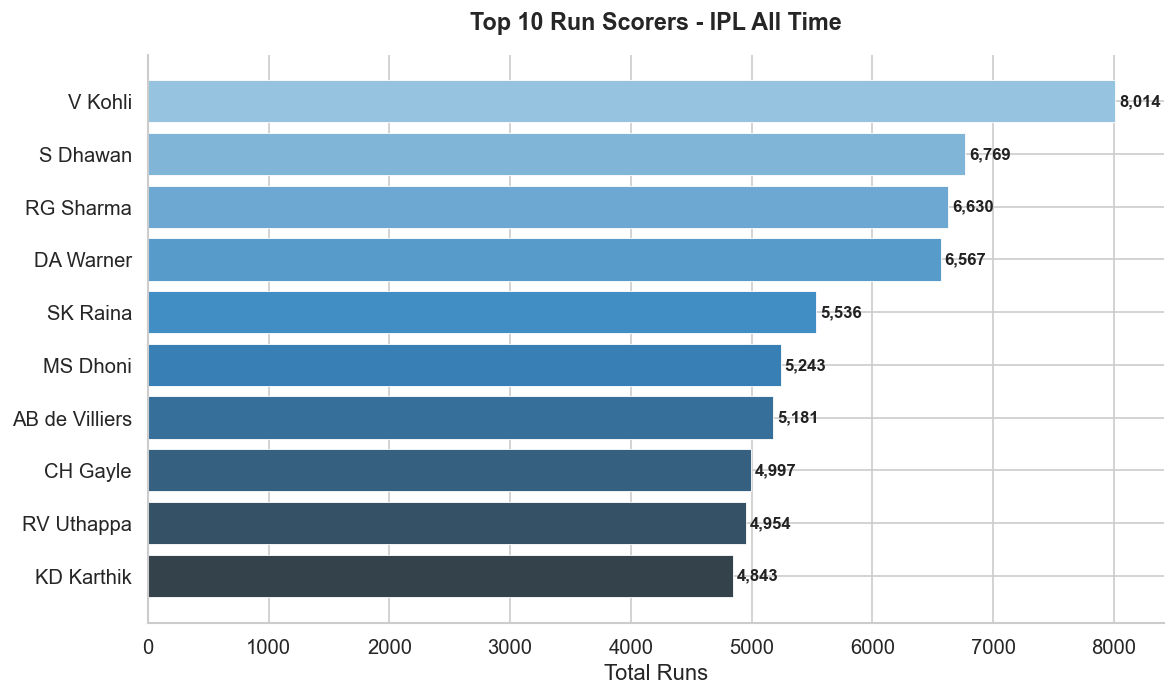

Saved: chart3_top_batters.png


In [43]:
# Chart 3: Top 10 all-time run scorers
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('Blues_d', len(top_batters))
bars = ax.barh(top_batters['Batter'][::-1], top_batters['Total Runs'][::-1],
               color=palette[::-1], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, top_batters['Total Runs'][::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=10, fontweight='bold', color='#222')
ax.set_title('Top 10 Run Scorers - IPL All Time', pad=15)
ax.set_xlabel('Total Runs')
ax.set_xlim(0, top_batters['Total Runs'].max() + 400)
plt.tight_layout()
plt.savefig('chart3_top_batters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart3_top_batters.png')


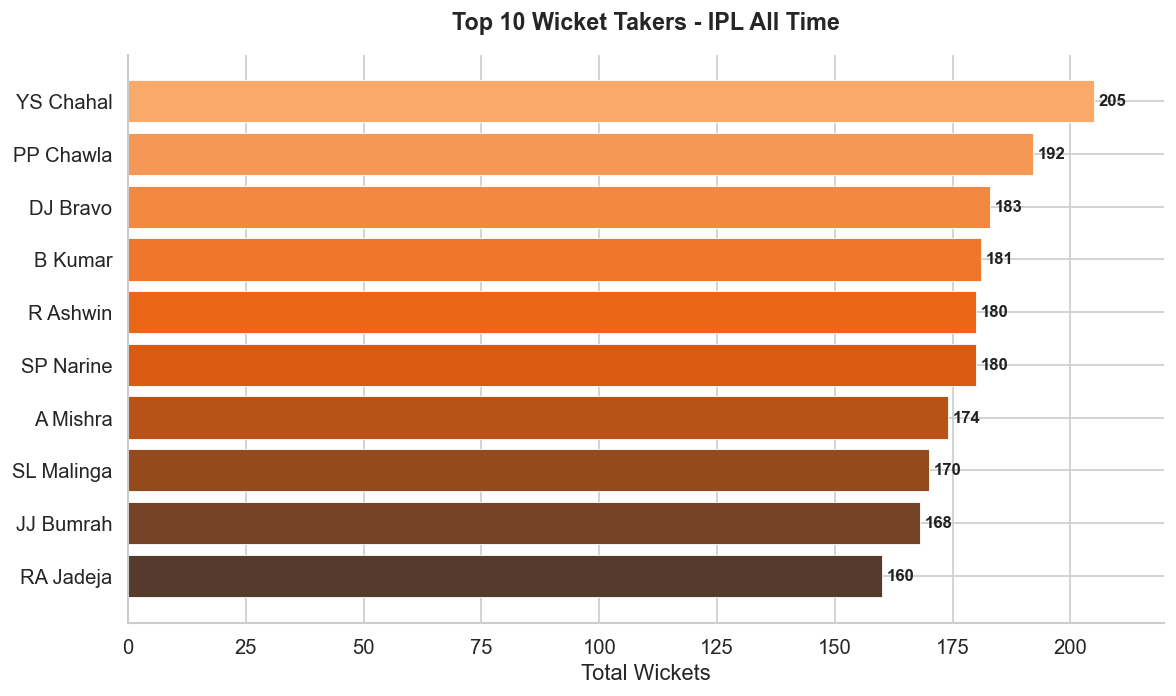

Saved: chart4_top_bowlers.png


In [44]:
# Chart 4: Top 10 wicket takers
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('Oranges_d', len(top_bowlers))
bars = ax.barh(top_bowlers['Bowler'][::-1], top_bowlers['Wickets'][::-1],
               color=palette[::-1], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, top_bowlers['Wickets'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=10, fontweight='bold', color='#222')
ax.set_title('Top 10 Wicket Takers - IPL All Time', pad=15)
ax.set_xlabel('Total Wickets')
ax.set_xlim(0, top_bowlers['Wickets'].max() + 15)
plt.tight_layout()
plt.savefig('chart4_top_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart4_top_bowlers.png')


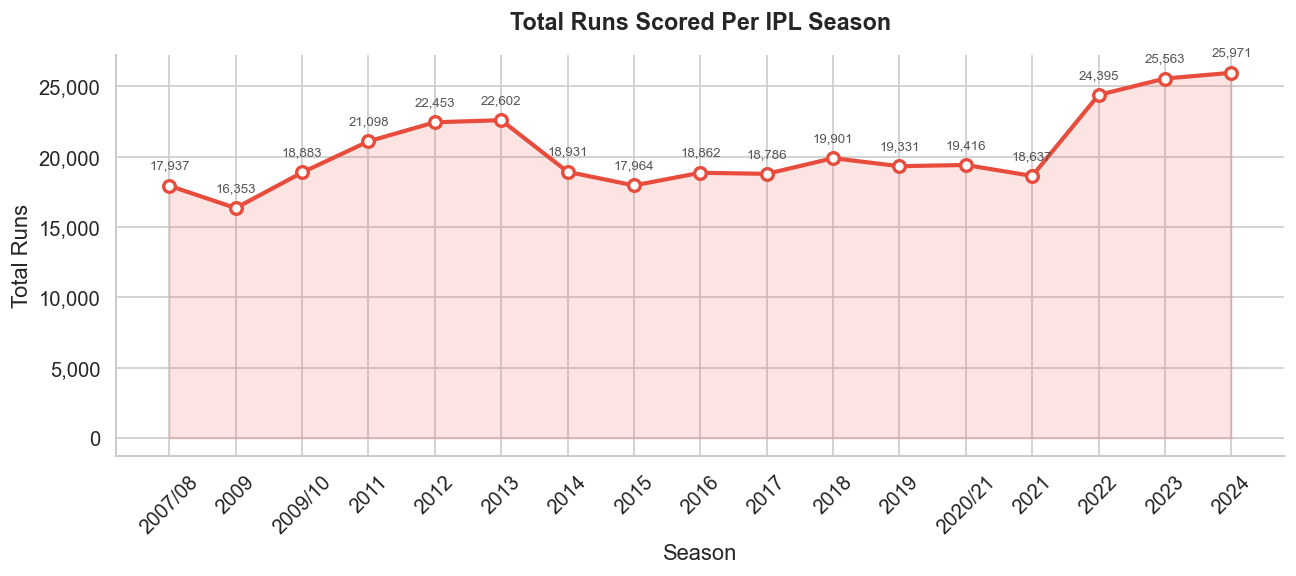

Saved: chart5_season_runs.png


In [45]:
# Chart 5: Season-wise total runs trend
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(season_runs['Season'], season_runs['Total Runs'], alpha=0.15, color='#e74c3c')
ax.plot(season_runs['Season'], season_runs['Total Runs'],
        color='#e74c3c', linewidth=2.5, marker='o', markersize=7,
        markerfacecolor='white', markeredgewidth=2)
for _, row in season_runs.iterrows():
    ax.annotate('{:,}'.format(int(row['Total Runs'])),
                (row['Season'], row['Total Runs']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8, color='#555')
ax.set_title('Total Runs Scored Per IPL Season', pad=15)
ax.set_xlabel('Season')
ax.set_ylabel('Total Runs')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:,}'.format(int(x))))
ax.set_xticks(season_runs['Season'])
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('chart5_season_runs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart5_season_runs.png')


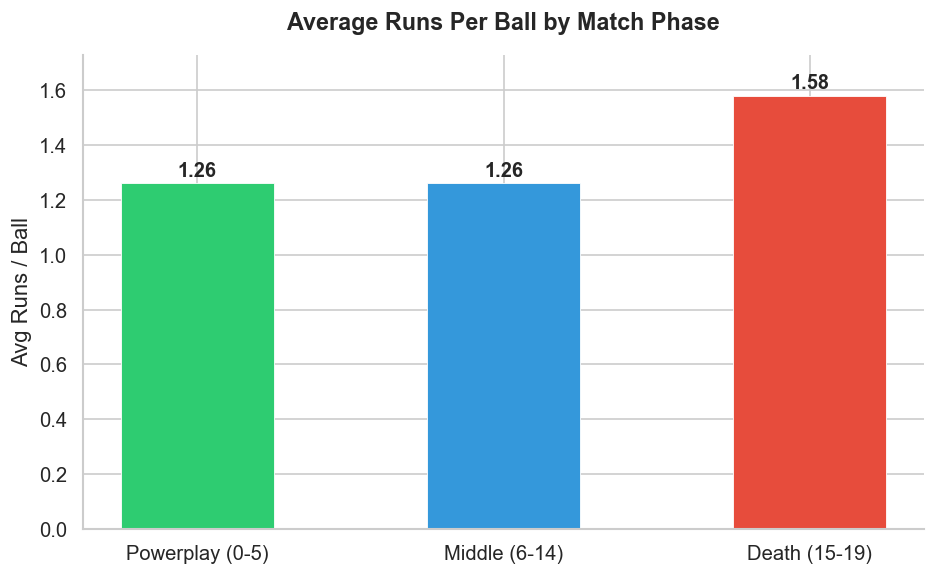

Saved: chart6_match_phases.png


In [46]:
# Chart 6: Scoring by match phase
fig, ax = plt.subplots(figsize=(8, 5))
phase_colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.bar(phase_avg['Phase'], phase_avg['Avg Runs/Ball'],
              color=phase_colors, edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, phase_avg['Avg Runs/Ball']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            '{:.2f}'.format(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Average Runs Per Ball by Match Phase', pad=15)
ax.set_ylabel('Avg Runs / Ball')
ax.set_ylim(0, phase_avg['Avg Runs/Ball'].max() + 0.15)
plt.tight_layout()
plt.savefig('chart6_match_phases.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart6_match_phases.png')


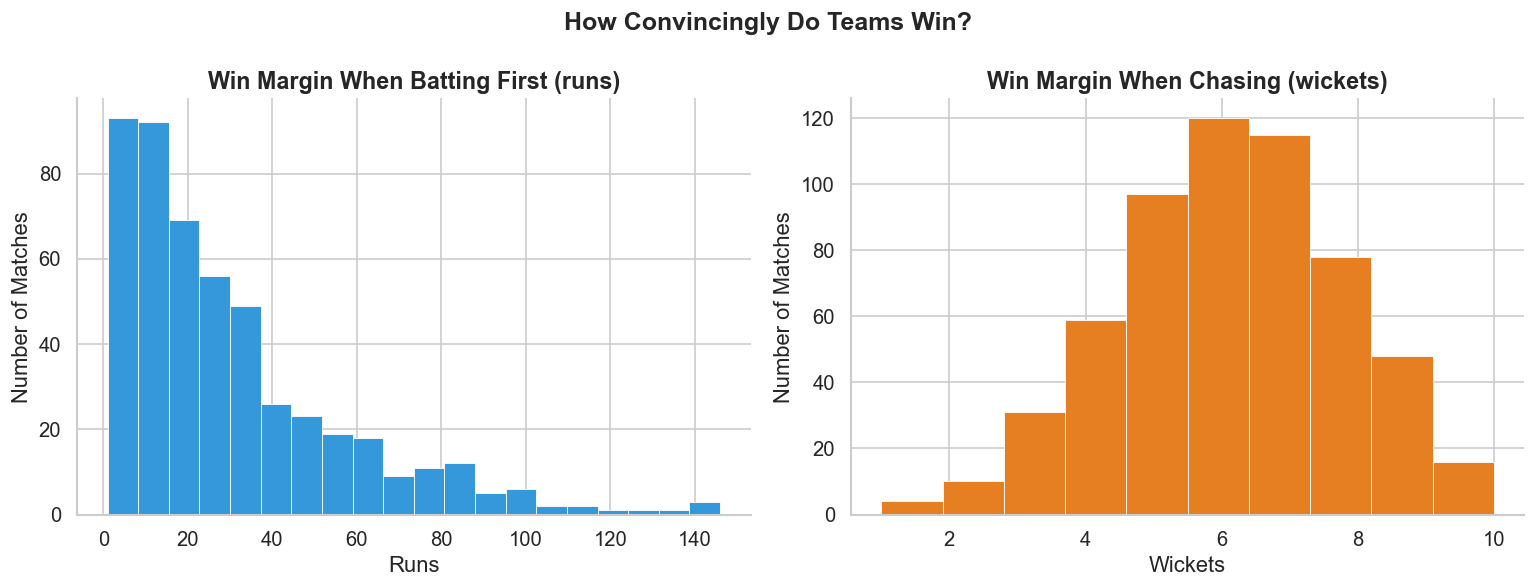

Saved: chart7_win_margins.png


In [47]:
# Chart 7: Win margin distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
run_wins    = matches_clean[matches_clean['result'] == 'runs']['result_margin'].dropna()
wicket_wins = matches_clean[matches_clean['result'] == 'wickets']['result_margin'].dropna()

axes[0].hist(run_wins, bins=20, color='#3498db', edgecolor='white', linewidth=0.5)
axes[0].set_title('Win Margin When Batting First (runs)')
axes[0].set_xlabel('Runs')
axes[0].set_ylabel('Number of Matches')

axes[1].hist(wicket_wins, bins=10, color='#e67e22', edgecolor='white', linewidth=0.5)
axes[1].set_title('Win Margin When Chasing (wickets)')
axes[1].set_xlabel('Wickets')
axes[1].set_ylabel('Number of Matches')

plt.suptitle('How Convincingly Do Teams Win?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_win_margins.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart7_win_margins.png')


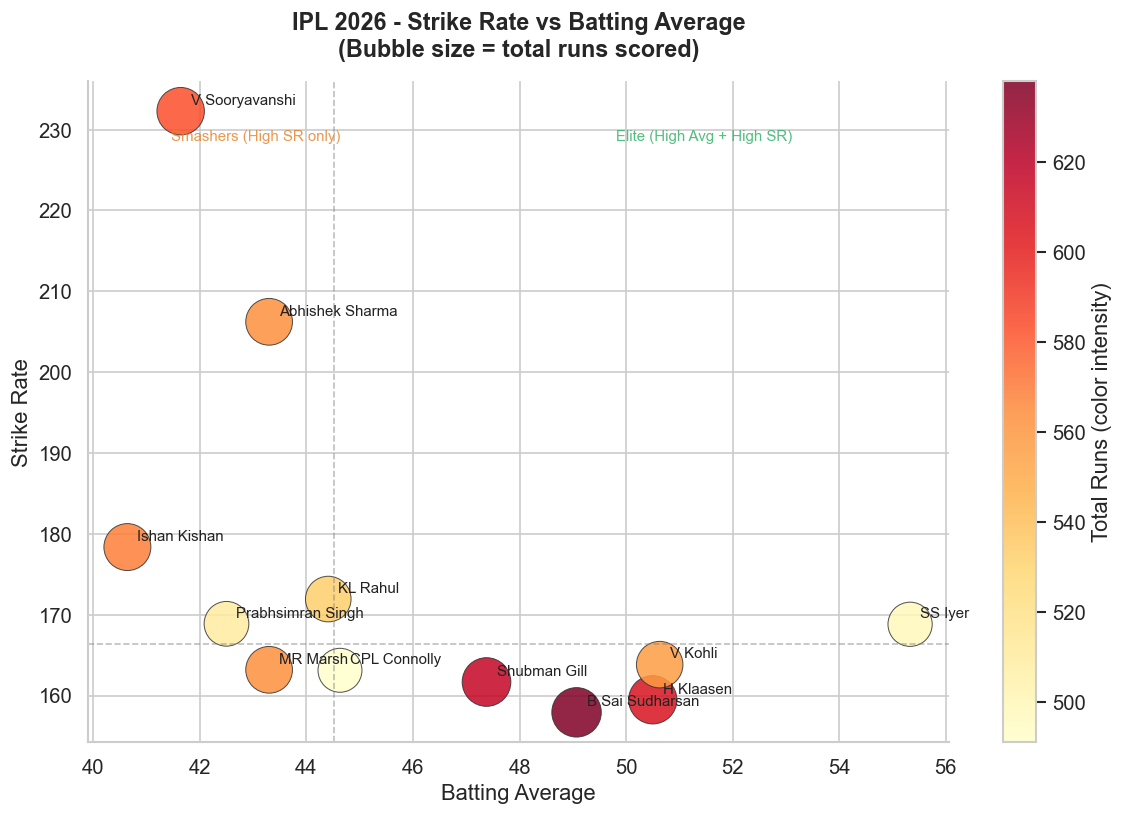

Saved: chart8_ipl2026_scatter.png
NOTE: This chart uses our SCRAPED IPL 2026 data!


In [ ]:
# Chart 8: IPL 2026 Strike Rate vs Average
fig, ax = plt.subplots(figsize=(10, 7))

df_plot = df_live.copy()
for col in ['Ave', 'SR', 'Runs']:
    if col in df_plot.columns:
        df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')
df_plot = df_plot.dropna(subset=['Ave', 'SR', 'Runs'])

scatter = ax.scatter(
    df_plot['Ave'], df_plot['SR'],
    s=df_plot['Runs'] / df_plot['Runs'].max() * 800 + 80,
    c=df_plot['Runs'], cmap='YlOrRd',
    alpha=0.85, edgecolors='#333', linewidth=0.6
)

player_col = 'Player' if 'Player' in df_plot.columns else df_plot.columns[0]
for _, row in df_plot.iterrows():
    ax.annotate(row[player_col], (row['Ave'], row['SR']),
                xytext=(6, 4), textcoords='offset points', fontsize=9, color='#222')

plt.colorbar(scatter, ax=ax, label='Total Runs (color intensity)')
ax.axvline(df_plot['Ave'].median(), color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(df_plot['SR'].median(), color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_title('IPL 2026 - Strike Rate vs Batting Average\n(Bubble size = total runs scored)', pad=15)
ax.set_xlabel('Batting Average')
ax.set_ylabel('Strike Rate')

ax.text(df_plot['Ave'].max()*0.96, df_plot['SR'].max()*0.99,
        'Elite (High Avg + High SR)', ha='right', va='top', fontsize=9, color='#27ae60', alpha=0.8)
ax.text(df_plot['Ave'].min()*1.02, df_plot['SR'].max()*0.99,
        'Smashers (High SR only)', ha='left', va='top', fontsize=9, color='#e67e22', alpha=0.8)

plt.tight_layout()
plt.savefig('chart8_ipl2026_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart8_ipl2026_scatter.png')
print('NOTE: This chart uses our SCRAPED IPL 2026 data!')
